<a href="https://colab.research.google.com/github/RaymCharles/Projet-CNN/blob/main/Projet_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet Machine Learning

## 1. Compréhension et préparation des données

### Task 1 - Chargement du dataset CIFAR-10

In [1]:
import tensorflow as tf

print("TensorFlow :", tf.__version__)
print("GPU disponible :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Bibliothèques de base
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow et Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Vérification de la version TensorFlow
print("Version TensorFlow :", tf.__version__)

Version TensorFlow : 2.20.0


In [3]:
# Chargement du dataset CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
# Affichage des dimensions du dataset

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de y_train :", y_train.shape)

print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_test :", y_test.shape)

Dimensions de X_train : (50000, 32, 32, 3)
Dimensions de y_train : (50000, 1)
Dimensions de X_test : (10000, 32, 32, 3)
Dimensions de y_test : (10000, 1)


#### Réponses aux questions

- Nombre d'images d'entraînement : 50 000
- Nombre d'images de test : 10 000

- Chaque image possède une dimension de 32 × 32 pixels.
- Les images possèdent 3 canaux de couleur (RGB : Red, Green, Blue).

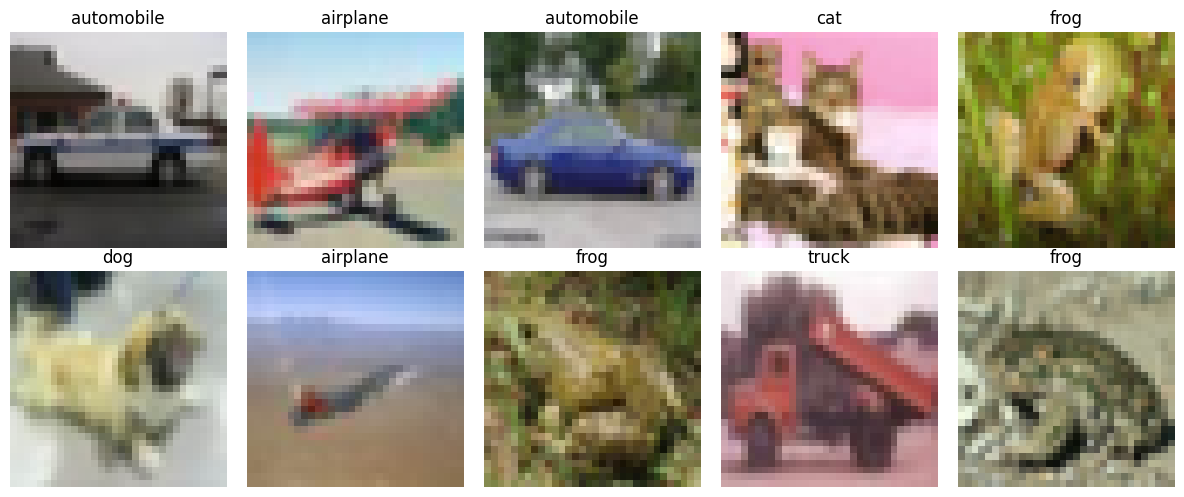

In [5]:
# Noms des classes CIFAR-10

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# Affichage de 10 images aléatoires

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    index = np.random.randint(0, len(X_train))

    plt.imshow(X_train[index])

    plt.title(class_names[y_train[index][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Analyse des images

Les images du dataset CIFAR-10 représentent différentes catégories d’objets telles que des avions, des voitures, des oiseaux, des chats ou encore des bateaux.

Les labels sont des données catégorielles. Ils sont initialement représentés par des valeurs numériques comprises entre 0 et 9, chaque valeur correspondant à une classe spécifique.

Les images sont relativement petites (32 × 32 pixels), ce qui rend certaines classes difficiles à distinguer. Pour un humain, certaines images sont facilement reconnaissables, tandis que d’autres peuvent être ambiguës en raison de leur faible résolution.

In [6]:
# Affichage de quelques labels

print("Premiers labels du dataset :")
print(y_train[:10].flatten())

Premiers labels du dataset :
[6 9 9 4 1 1 2 7 8 3]


#### Nature des labels

Les labels sont stockés sous forme de nombres entiers compris entre 0 et 9.

Cependant, ces valeurs numériques ne représentent pas des quantités mais des catégories d’objets (avion, voiture, chat, chien, etc.).

Les labels sont donc des données catégorielles encodées numériquement.

In [7]:
# Vérification des valeurs des pixels avant normalisation

print("Valeur minimale :", X_train.min())
print("Valeur maximale :", X_train.max())

Valeur minimale : 0
Valeur maximale : 255


In [8]:
# Normalisation des images

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [9]:
# Vérification après normalisation

print("Valeur minimale :", X_train.min())
print("Valeur maximale :", X_train.max())

Valeur minimale : 0.0
Valeur maximale : 1.0


#### Pourquoi normaliser les données ?

La normalisation consiste à ramener les valeurs des pixels de l’intervalle [0,255] vers l’intervalle [0,1].

Cette étape est importante car elle permet d’éviter que certaines caractéristiques aient des valeurs beaucoup plus grandes que d’autres. Elle facilite également le calcul du gradient lors de l’apprentissage.

#### Impact de la normalisation sur les réseaux de neurones

La normalisation améliore la stabilité numérique du modèle et accélère la convergence pendant l’entraînement.

Elle permet généralement d’obtenir un apprentissage plus rapide, plus stable et de meilleures performances de classification.

In [10]:
# Forme des labels avant one-hot encoding

print("y_train shape avant encodage :", y_train.shape)
print("Exemple de label avant encodage :", y_train[0])

y_train shape avant encodage : (50000, 1)
Exemple de label avant encodage : [6]


In [11]:
# One-hot encoding des labels

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [12]:
# Vérification après one-hot encoding

print("y_train_cat shape après encodage :", y_train_cat.shape)
print("Exemple de label après encodage :", y_train_cat[0])

y_train_cat shape après encodage : (50000, 10)
Exemple de label après encodage : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


#### One-Hot Encoding des labels

Le one-hot encoding transforme chaque label numérique en un vecteur binaire de taille égale au nombre de classes.

Dans CIFAR-10, il y a 10 classes. Un label comme `3` est donc transformé en un vecteur contenant dix valeurs, avec un `1` à la position correspondant à la classe et des `0` ailleurs.

Cette transformation est nécessaire pour un problème de classification multi-classes lorsque l’on utilise une couche de sortie avec 10 neurones et une fonction d’activation softmax.

Elle permet au réseau de comparer ses prédictions, qui sont des probabilités pour chaque classe, avec la vraie classe représentée sous forme de vecteur.

In [13]:
# Comptage du nombre d'images par classe

unique, counts = np.unique(y_train, return_counts=True)

for classe, nombre in zip(unique, counts):
    print(f"{class_names[classe]} : {nombre}")

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


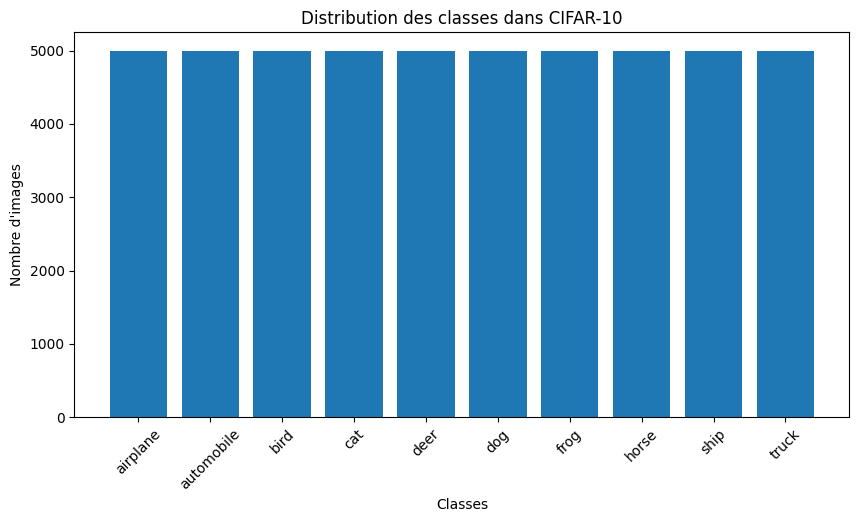

In [14]:
# Distribution des classes

plt.figure(figsize=(10, 5))

plt.bar(class_names, counts)

plt.title("Distribution des classes dans CIFAR-10")
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")

plt.xticks(rotation=45)

plt.show()

#### Analyse de la distribution des classes

Le graphique montre que chaque classe contient 5000 images dans l’ensemble d’entraînement.

Le dataset CIFAR-10 est donc équilibré puisque toutes les classes sont représentées par le même nombre d’exemples.

L’analyse de la distribution des classes est importante avant l’entraînement d’un modèle car un déséquilibre pourrait entraîner un biais du modèle vers les classes majoritaires. Dans le cas de CIFAR-10, ce problème n’existe pas puisque les classes sont uniformément réparties.

## 2. Modélisation des données

### Modèle 1 - LeNet5

In [15]:
# Importation des outils nécessaires pour construire les CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam

In [16]:
# Définition du modèle LeNet5

def build_lenet5():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    model.add(Conv2D(6, kernel_size=(5, 5), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(16, kernel_size=(5, 5), activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(120, activation="relu"))
    model.add(Dense(84, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model

In [17]:
# Création et affichage du résumé du modèle LeNet5

lenet5_model = build_lenet5()
lenet5_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compilation du modèle LeNet5 avec SGD

lenet5_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
# Entraînement du modèle

history_lenet5_sgd = lenet5_model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.0993 - loss: 2.3025 - val_accuracy: 0.1158 - val_loss: 2.2954
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1153 - loss: 2.2896 - val_accuracy: 0.1179 - val_loss: 2.2810
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1296 - loss: 2.2689 - val_accuracy: 0.1463 - val_loss: 2.2498
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1735 - loss: 2.2189 - val_accuracy: 0.2205 - val_loss: 2.1699
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2344 - loss: 2.1084 - val_accuracy: 0.2613 - val_loss: 2.0432
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2614 - loss: 2.0160 - val_accuracy: 0.2721 - val_loss: 1.9899
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2756 - loss: 1.9766 - val_accuracy: 0.2864 - val_loss: 1.9606
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2910 - loss: 1.9466 - val_accuracy: 0.

In [20]:
# Fonction d'affichage des courbes d'apprentissage

def plot_history(history):

    # Courbe de loss
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title('Evolution de la fonction de perte')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Courbe d'accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title("Evolution de l'accuracy")
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

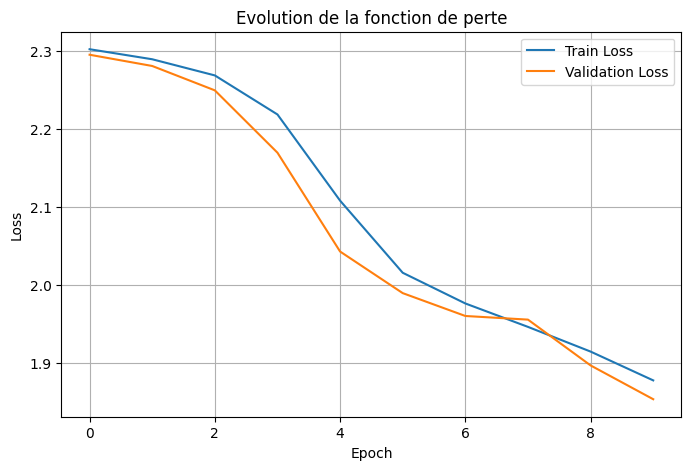

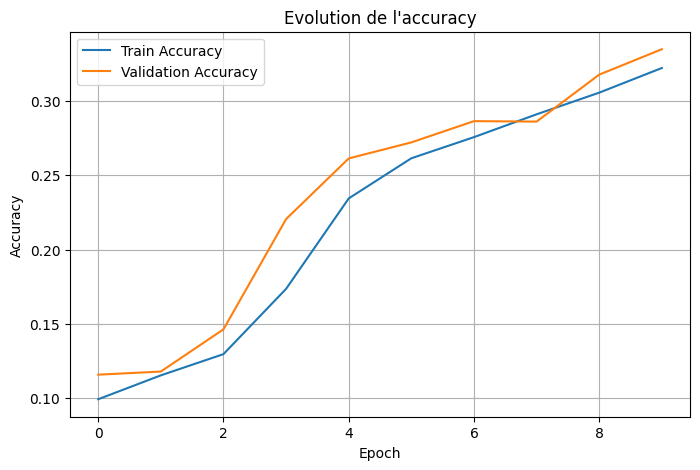

In [21]:
# Affichage des courbes pour LeNet5 + SGD

plot_history(history_lenet5_sgd)

In [22]:
# Evaluation finale du modèle LeNet5 avec SGD

train_loss = history_lenet5_sgd.history["loss"][-1]
train_acc = history_lenet5_sgd.history["accuracy"][-1]

val_loss = history_lenet5_sgd.history["val_loss"][-1]
val_acc = history_lenet5_sgd.history["val_accuracy"][-1]

print("LeNet5 + SGD")
print("Train Loss :", train_loss)
print("Train Accuracy :", train_acc)
print("Validation Loss :", val_loss)
print("Validation Accuracy :", val_acc)

LeNet5 + SGD
Train Loss : 1.8780333995819092
Train Accuracy : 0.322160005569458
Validation Loss : 1.8538950681686401
Validation Accuracy : 0.33480000495910645


In [23]:
# Stockage des résultats dans une liste

results = []

results.append({
    "Model": "LeNet5",
    "Optimizer": "SGD",
    "Learning Rate": 0.001,
    "Epochs": 10,
    "Train Loss": train_loss,
    "Train Accuracy": train_acc,
    "Validation Loss": val_loss,
    "Validation Accuracy": val_acc
})

In [24]:
# Affichage des résultats sous forme de tableau

import pandas as pd

results_df = pd.DataFrame(results)
results_df

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,10,1.878033,0.32216,1.853895,0.3348


### Modèle 2 - VGG1

In [25]:
# Définition du modèle VGG1

def build_vgg1():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    # Bloc VGG 1
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Classification
    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model

In [26]:
# Création et affichage du résumé du modèle VGG1

vgg1_model = build_vgg1()
vgg1_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Compilation du modèle VGG1 avec SGD

vgg1_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
# Entraînement du modèle VGG1

history_vgg1_sgd = vgg1_model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.1788 - loss: 2.2504 - val_accuracy: 0.2304 - val_loss: 2.1836
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2597 - loss: 2.1109 - val_accuracy: 0.2737 - val_loss: 2.0368
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3087 - loss: 1.9786 - val_accuracy: 0.3160 - val_loss: 1.9319
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3351 - loss: 1.9017 - val_accuracy: 0.3294 - val_loss: 1.8904
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3524 - loss: 1.8560 - val_accuracy: 0.3354 - val_loss: 1.8597
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3668 - loss: 1.8186 - val_accuracy: 0.3573 - val_loss: 1.8166
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3779 - loss: 1.7826 - val_accuracy: 0.3601 - val_loss: 1.7900
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3922 - loss: 1.7476 - val_accuracy: 0.

### Modèle 3 - VGG2

In [29]:
# Définition du modèle VGG2

def build_vgg2():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    # Bloc VGG 1
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Bloc VGG 2
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Classification
    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model

In [30]:
# Création et affichage du résumé du modèle VGG2

vgg2_model = build_vgg2()
vgg2_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,202 (1.11 MB)

 Trainable params: 292,202 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

### Modèle 4 - VGG3

In [31]:
# Définition du modèle VGG3

def build_vgg3():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    for i in range(3):
        model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
        model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model

In [32]:
# Création et affichage du résumé du modèle VGG3

vgg3_model = build_vgg3()
vgg3_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,090 (445.66 KB)

 Trainable params: 114,090 (445.66 KB)

 Non-trainable params: 0 (0.00 B)

### Modèle 5 - VGG3 avec Dropout

In [33]:
# Importation de la couche Dropout

from tensorflow.keras.layers import Dropout

In [34]:
# Définition du modèle VGG3 avec Dropout

def build_vgg3_dropout():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    for i in range(3):
        model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
        model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation="softmax"))

    return model

In [35]:
# Création et affichage du résumé du modèle VGG3 avec Dropout

vgg3_dropout_model = build_vgg3_dropout()
vgg3_dropout_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,090 (445.66 KB)

 Trainable params: 114,090 (445.66 KB)

 Non-trainable params: 0 (0.00 B)

### Modèle 6 - VGG3 avec Dropout et Batch Normalization

In [36]:
# Importation de BatchNormalization

from tensorflow.keras.layers import BatchNormalization

In [37]:
# Définition du modèle VGG3 avec Dropout et Batch Normalization

def build_vgg3_dropout_bn():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    for i in range(3):

        model.add(Conv2D(32, kernel_size=(3, 3), padding="same"))
        model.add(BatchNormalization())
        model.add(tf.keras.layers.Activation("relu"))

        model.add(Conv2D(32, kernel_size=(3, 3), padding="same"))
        model.add(BatchNormalization())
        model.add(tf.keras.layers.Activation("relu"))

        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(tf.keras.layers.Activation("relu"))

    model.add(Dropout(0.5))

    model.add(Dense(10, activation="softmax"))

    return model

In [38]:
# Création et affichage du résumé du modèle

vgg3_dropout_bn_model = build_vgg3_dropout_bn()
vgg3_dropout_bn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             

 Total params: 115,370 (450.66 KB)

 Trainable params: 114,730 (448.16 KB)

 Non-trainable params: 640 (2.50 KB)

In [39]:
# Fonction générique d'entraînement d'un modèle

def train_model(model_builder, model_name, optimizer_name, learning_rate, epochs=50, batch_size=64):

    # Création d'un nouveau modèle à chaque entraînement
    model = model_builder()

    # Choix de l'optimiseur
    if optimizer_name == "SGD":
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_name == "Adam":
        optimizer = Adam(learning_rate=learning_rate)
    else:
        raise ValueError("Optimizer not supported")

    # Compilation du modèle
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Entraînement du modèle
    history = model.fit(
        X_train,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test_cat),
        verbose=1
    )

    # Récupération des résultats finaux
    result = {
        "Model": model_name,
        "Optimizer": optimizer_name,
        "Learning Rate": learning_rate,
        "Epochs": epochs,
        "Train Loss": history.history["loss"][-1],
        "Train Accuracy": history.history["accuracy"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1]
    }

    return model, history, result

In [40]:
# Liste des modèles à comparer

model_builders = {
    "LeNet5": build_lenet5,
    "VGG1": build_vgg1,
    "VGG2": build_vgg2,
    "VGG3": build_vgg3,
    "VGG3 + Dropout": build_vgg3_dropout,
    "VGG3 + Dropout + BatchNorm": build_vgg3_dropout_bn
}

# Optimiseurs à tester
optimizers = ["SGD", "Adam"]

# Learning rates indiqués dans le sujet
learning_rates = [0.001, 0.01, 0.1]

# Nombre d'epochs indiqué dans le sujet
epochs = 50

In [41]:
# Expérience officielle 1 : LeNet5 + SGD + LR = 0.001

official_results = []

model_lenet5_sgd_001, history_lenet5_sgd_001, result_lenet5_sgd_001 = train_model(
    model_builder=build_lenet5,
    model_name="LeNet5",
    optimizer_name="SGD",
    learning_rate=0.001,
    epochs=50,
    batch_size=64
)

official_results.append(result_lenet5_sgd_001)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.1073 - loss: 2.3051 - val_accuracy: 0.1419 - val_loss: 2.2899
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1519 - loss: 2.2794 - val_accuracy: 0.1545 - val_loss: 2.2635
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1895 - loss: 2.2344 - val_accuracy: 0.2167 - val_loss: 2.1940
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2354 - loss: 2.1330 - val_accuracy: 0.2633 - val_loss: 2.0720
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2740 - loss: 2.0223 - val_accuracy: 0.2789 - val_loss: 1.9887
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2952 - loss: 1.9635 - val_accuracy: 0.3042 - val_loss: 1.9531
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3101 - loss: 1.9261 - val_accuracy: 0.3132 - val_loss: 1.9191
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3228 - loss: 1.8937 - val_accuracy: 0.

In [42]:
official_results_df = pd.DataFrame(official_results)
official_results_df

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.303885,0.53536,1.314858,0.5303


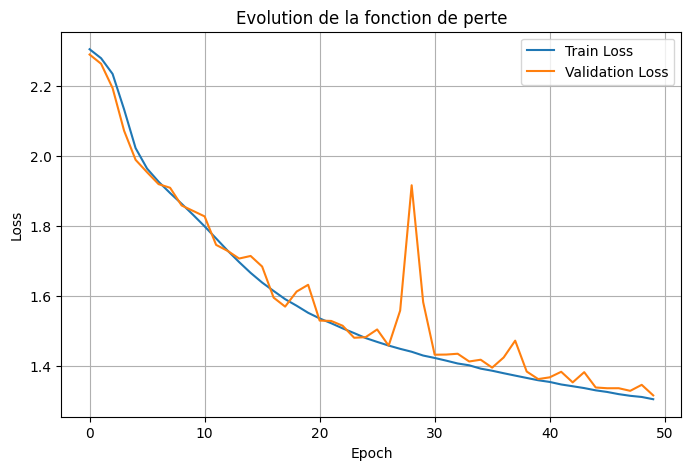

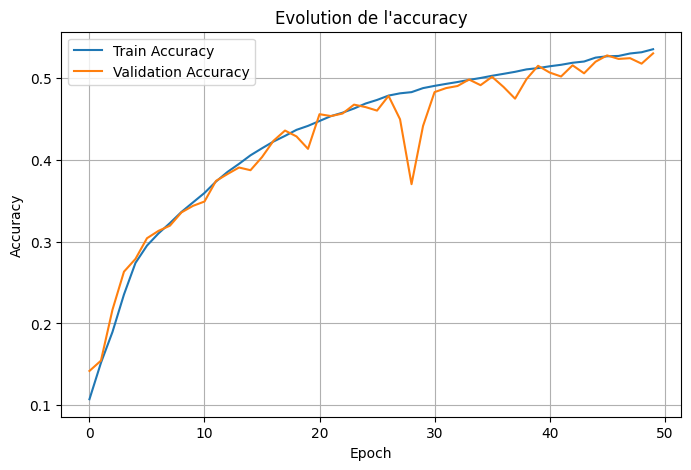

In [43]:
plot_history(history_lenet5_sgd_001)

#### Analyse des courbes d'apprentissage

La fonction de perte diminue progressivement sur les ensembles d'entraînement et de validation, ce qui montre que le modèle apprend correctement au cours des époques.

Les deux courbes restent proches pendant l'entraînement, ce qui indique une bonne capacité de généralisation et l'absence d'overfitting significatif.

On observe une augmentation ponctuelle de la perte de validation autour de l'époque 28. Cependant, cette fluctuation disparaît rapidement et n'affecte pas la tendance globale du modèle.

In [44]:
# Expériences officielles pour LeNet5 uniquement

for optimizer_name in optimizers:
    for lr in learning_rates:

        # Eviter de refaire l'expérience déjà réalisée
        if optimizer_name == "SGD" and lr == 0.001:
            continue

        print("=" * 60)
        print(f"Entraînement : LeNet5 | Optimizer = {optimizer_name} | LR = {lr}")
        print("=" * 60)

        model, history, result = train_model(
            model_builder=build_lenet5,
            model_name="LeNet5",
            optimizer_name=optimizer_name,
            learning_rate=lr,
            epochs=50,
            batch_size=64
        )

        official_results.append(result)

Entraînement : LeNet5 | Optimizer = SGD | LR = 0.01
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2082 - loss: 2.1552 - val_accuracy: 0.2605 - val_loss: 1.9989
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3443 - loss: 1.8311 - val_accuracy: 0.3760 - val_loss: 1.7247
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4065 - loss: 1.6595 - val_accuracy: 0.4241 - val_loss: 1.6122
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4409 - loss: 1.5666 - val_accuracy: 0.4125 - val_loss: 1.6465
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4649 - loss: 1.4959 - val_accuracy: 0.4719 - val_loss: 1.4706
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4877 - loss: 1.4408 - val_accuracy: 0.4857 - val_loss: 1.4341
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5026 - loss: 1.3950 - val_accuracy: 0.4873 - val_loss: 1.4369
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step 

In [45]:
official_results_df = pd.DataFrame(official_results)
official_results_df

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.303885,0.53536,1.314858,0.5303
1,LeNet5,SGD,0.010,50,0.732028,0.74328,1.351622,0.5767
2,LeNet5,SGD,0.100,50,0.421945,0.85794,2.504366,0.5626
3,LeNet5,Adam,0.001,50,0.157766,0.94302,2.858409,0.6105
4,LeNet5,Adam,0.010,50,2.303646,0.09870,2.303233,0.1000
5,LeNet5,Adam,0.100,50,2.312176,0.09780,2.312973,0.1000


In [46]:
# Expériences officielles pour VGG1 uniquement

for optimizer_name in optimizers:
    for lr in learning_rates:

        print("=" * 60)
        print(f"Entraînement : VGG1 | Optimizer = {optimizer_name} | LR = {lr}")
        print("=" * 60)

        model, history, result = train_model(
            model_builder=build_vgg1,
            model_name="VGG1",
            optimizer_name=optimizer_name,
            learning_rate=lr,
            epochs=50,
            batch_size=64
        )

        official_results.append(result)

Entraînement : VGG1 | Optimizer = SGD | LR = 0.001
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.1604 - loss: 2.2617 - val_accuracy: 0.2088 - val_loss: 2.2070
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2507 - loss: 2.1233 - val_accuracy: 0.2726 - val_loss: 2.0467
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3076 - loss: 1.9831 - val_accuracy: 0.3232 - val_loss: 1.9474
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3387 - loss: 1.9038 - val_accuracy: 0.3375 - val_loss: 1.8823
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3545 - loss: 1.8572 - val_accuracy: 0.3369 - val_loss: 1.8684
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3685 - loss: 1.8190 - val_accuracy: 0.3667 - val_loss: 1.8151
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3783 - loss: 1.7863 - val_accuracy: 0.3830 - val_loss: 1.7767
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step -

In [47]:
official_results_df = pd.DataFrame(official_results)
official_results_df

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.303885,0.53536,1.314858,0.5303
1,LeNet5,SGD,0.010,50,0.732028,0.74328,1.351622,0.5767
2,LeNet5,SGD,0.100,50,0.421945,0.85794,2.504366,0.5626
3,LeNet5,Adam,0.001,50,0.157766,0.94302,2.858409,0.6105
4,LeNet5,Adam,0.010,50,2.303646,0.09870,2.303233,0.1000
5,LeNet5,Adam,0.100,50,2.312176,0.09780,2.312973,0.1000
6,VGG1,SGD,0.001,50,1.106160,0.61364,1.223190,0.5595
7,VGG1,SGD,0.010,50,0.087208,0.97934,2.332007,0.6382
8,VGG1,SGD,0.100,50,0.000037,1.00000,3.777834,0.6751
9,VGG1,Adam,0.001,50,0.025578,0.99168,4.414308,0.6648
